In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
import sunpy.visualization.colormaps as sunpycm
from sunpy.visualization.colormaps import color_tables
import torch
from omegaconf import OmegaConf
from loguru import logger as lgr_logger

from sdofmv2.core import MAE, MAE_old, SDOMLDataModule, inverse_log_norm
from sdofmv2.utils import ALL_WAVELENGTHS, ALL_COMPONENTS

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cfg = OmegaConf.load(
    "../../../configs/pretrain/pretrain_mae_ALL.yaml"
    )

In [3]:
def get_file_name(file_path: str):
    file = Path(file_path)
    return file.name

cache_dir = "../../../assets/cache/ALL/"
train_index = get_file_name(cfg.data.train_index)
val_index = get_file_name(cfg.data.val_index)
test_index = get_file_name(cfg.data.test_index)

data_module = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg.data.sdoml.base_directory, 
        cfg.data.sdoml.sub_directory.hmi
    ) if cfg.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg.data.sdoml.base_directory,
        cfg.data.sdoml.sub_directory.aia,
    ) if cfg.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    train_index=cache_dir + train_index,
    val_index=cache_dir + val_index,
    test_index=cache_dir + test_index,
    num_frames=cfg.model.mae.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    apply_mask=cfg.data.sdoml.apply_mask,
    precision=cfg.experiment.precision,
    normalization=cfg.data.sdoml.normalization,
    normalization_stat_path=cache_dir,
)
data_module.setup()

2026-06-19 20:09:51.165 | INFO     | sdofmv2.core.datamodule:setup:635 - Train dataloader is ready!
2026-06-19 20:09:51.166 | INFO     | sdofmv2.core.datamodule:setup:636 - Dataset size: 223044
2026-06-19 20:09:51.312 | INFO     | sdofmv2.core.datamodule:setup:654 - Validation dataloader is ready!
2026-06-19 20:09:51.314 | INFO     | sdofmv2.core.datamodule:setup:655 - Dataset size: 23123
2026-06-19 20:09:51.419 | INFO     | sdofmv2.core.datamodule:setup:673 - test dataloader is ready!
2026-06-19 20:09:51.421 | INFO     | sdofmv2.core.datamodule:setup:674 - Dataset size: 24618


In [4]:
aia_list = (
    ALL_WAVELENGTHS
    if cfg.data.sdoml.sub_directory.aia and cfg.data.sdoml.wavelengths is None
    else cfg.data.sdoml.wavelengths or []
)

hmi_list = (
    ALL_COMPONENTS
    if cfg.data.sdoml.sub_directory.hmi and cfg.data.sdoml.components is None
    else cfg.data.sdoml.components or []
)

aia_list.sort()
hmi_list.sort()
chan_types = aia_list + hmi_list

cms = [
    sunpycm.cmlist.get("sdoaia131"),
    sunpycm.cmlist.get("sdoaia1600"),
    sunpycm.cmlist.get("sdoaia1700"),
    sunpycm.cmlist.get("sdoaia171"),
    sunpycm.cmlist.get("sdoaia193"),
    sunpycm.cmlist.get("sdoaia211"),
    sunpycm.cmlist.get("sdoaia304"),
    sunpycm.cmlist.get("sdoaia335"),
    sunpycm.cmlist.get("sdoaia94"),
    color_tables.hmi_mag_color_table(),
    color_tables.hmi_mag_color_table(),
    color_tables.hmi_mag_color_table(),
]

In [5]:
ckpt_dir = "../../../assets/checkpoints/backbone/"
model = MAE.load_from_checkpoint(
    checkpoint_path=ckpt_dir+"ALL/id_tnzqmrb2_mae_epoch=4-step=3600-val_loss=0.06.ckpt", 
    map_location="cpu",
    weights_only=False)
lgr_logger.info(f"masking ratio of sdofmv2: {model.masking_ratio}")

2026-06-19 20:10:00.300 | INFO     | __main__:<module>:6 - masking ratio of sdofmv2: 0.2


In [6]:
timestamps = [
    "2011-12-25 00:12:00",
    ]

img_indices = [
    data_module.test_ds.aligndata.index.get_loc(
        pd.to_datetime(i_time)
    ) for i_time in timestamps
]

x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]
print(f"Datetime: {ts}")

Datetime: [Timestamp('2011-12-25 00:12:00')]


In [7]:
model.eval()

with torch.no_grad():
    output_25 = model(x_set, mask_ratio=0.25)
    output_50 = model(x_set, mask_ratio=0.50)
    output_85 = model(x_set, mask_ratio=0.85)

In [8]:
type(output_25[0])

torch.Tensor

In [9]:
x_set_denorm = x_set.clone()
output_25_denorm = output_25[0].clone()
output_50_denorm = output_50[0].clone()
output_85_denorm = output_85[0].clone()

# inverse transformation of hmi
for i_img in range(x_set.shape[0]):
    for ch_id, ch in enumerate(chan_types[-3:]):

        x_set_denorm[i_img, ch_id+9, 0, :, :] = inverse_log_norm(
            x_set[i_img, ch_id+9, 0, :, :],
            data_module.normalization_stat,
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
        )

        output_25_denorm[i_img, ch_id+9, 0, :, :] = inverse_log_norm(
            output_25[0][i_img, ch_id+9, 0, :, :],
            data_module.normalization_stat,
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
        )

        output_50_denorm[i_img, ch_id+9, 0, :, :] = inverse_log_norm(
            output_50[0][i_img, ch_id+9, 0, :, :],
            data_module.normalization_stat,
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
        )

        output_85_denorm[i_img, ch_id+9, 0, :, :] = inverse_log_norm(
            output_85[0][i_img, ch_id+9, 0, :, :],
            data_module.normalization_stat,
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
        )

In [10]:
def visualize_masked_regions(model_output, mask):

    patch_size = 16
    # visualize masking
    mask_grid = mask.reshape(512 // patch_size, 512 // patch_size)
    mask_full = np.kron(mask_grid, np.ones((patch_size, patch_size)))
    mask_full = torch.tensor(mask_full, dtype=bool)
    
    results = []
    for ch_id in range(12):
        img_slice = model_output[0, ch_id, 0, :, :].cpu().numpy()
        isolated_regions = np.where(~mask_full.cpu().numpy(), img_slice, np.nan)
        results.append(isolated_regions)

    return np.stack(results, axis=0)

def clean_limb(model_output):

    results = []
    for ch_id in range(12):
        img_ch = model_output[0, ch_id, 0, :, :].cpu().numpy()
        results.append(img_ch)

    return np.stack(results, axis=0)

In [11]:
masked_output = []
output_list = [
    (output_25_denorm, output_25[1][0]),
    (output_50_denorm, output_50[1][0]),
    (output_85_denorm, output_85[1][0])
]
for i, (output, mask) in enumerate(output_list):
    masked_output.append(visualize_masked_regions(output, mask))

# error list
error_list = [
    output_25[0] - x_set,
    output_50[0] - x_set,
    output_85[0] - x_set
]

norm_aia = []
norm_hmi = []

for i in range(3):
    # error norm for AIA
    err_mp_mask_aia = error_list[i][0, :9, 0, :, :]
    lim_aia = np.nanquantile(np.abs(err_mp_mask_aia), 0.9999)
    # print("aia", lim_aia)
    norm_aia.append(TwoSlopeNorm(vmin=-lim_aia, vcenter=0, vmax=lim_aia))

    # error norm for HMI
    err_mp_mask_hmi = error_list[i][0, 9:, 0, :, :]
    lim_hmi = np.nanquantile(np.abs(err_mp_mask_hmi), 0.9999)
    # print("hmi", lim_hmi)
    norm_hmi.append(TwoSlopeNorm(vmin=-lim_hmi, vcenter=0, vmax=lim_hmi))

/tmp/ipykernel_688446/1138071910.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  lim_aia = np.nanquantile(np.abs(err_mp_mask_aia), 0.9999)
/tmp/ipykernel_688446/1138071910.py:29: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  lim_hmi = np.nanquantile(np.abs(err_mp_mask_hmi), 0.9999)


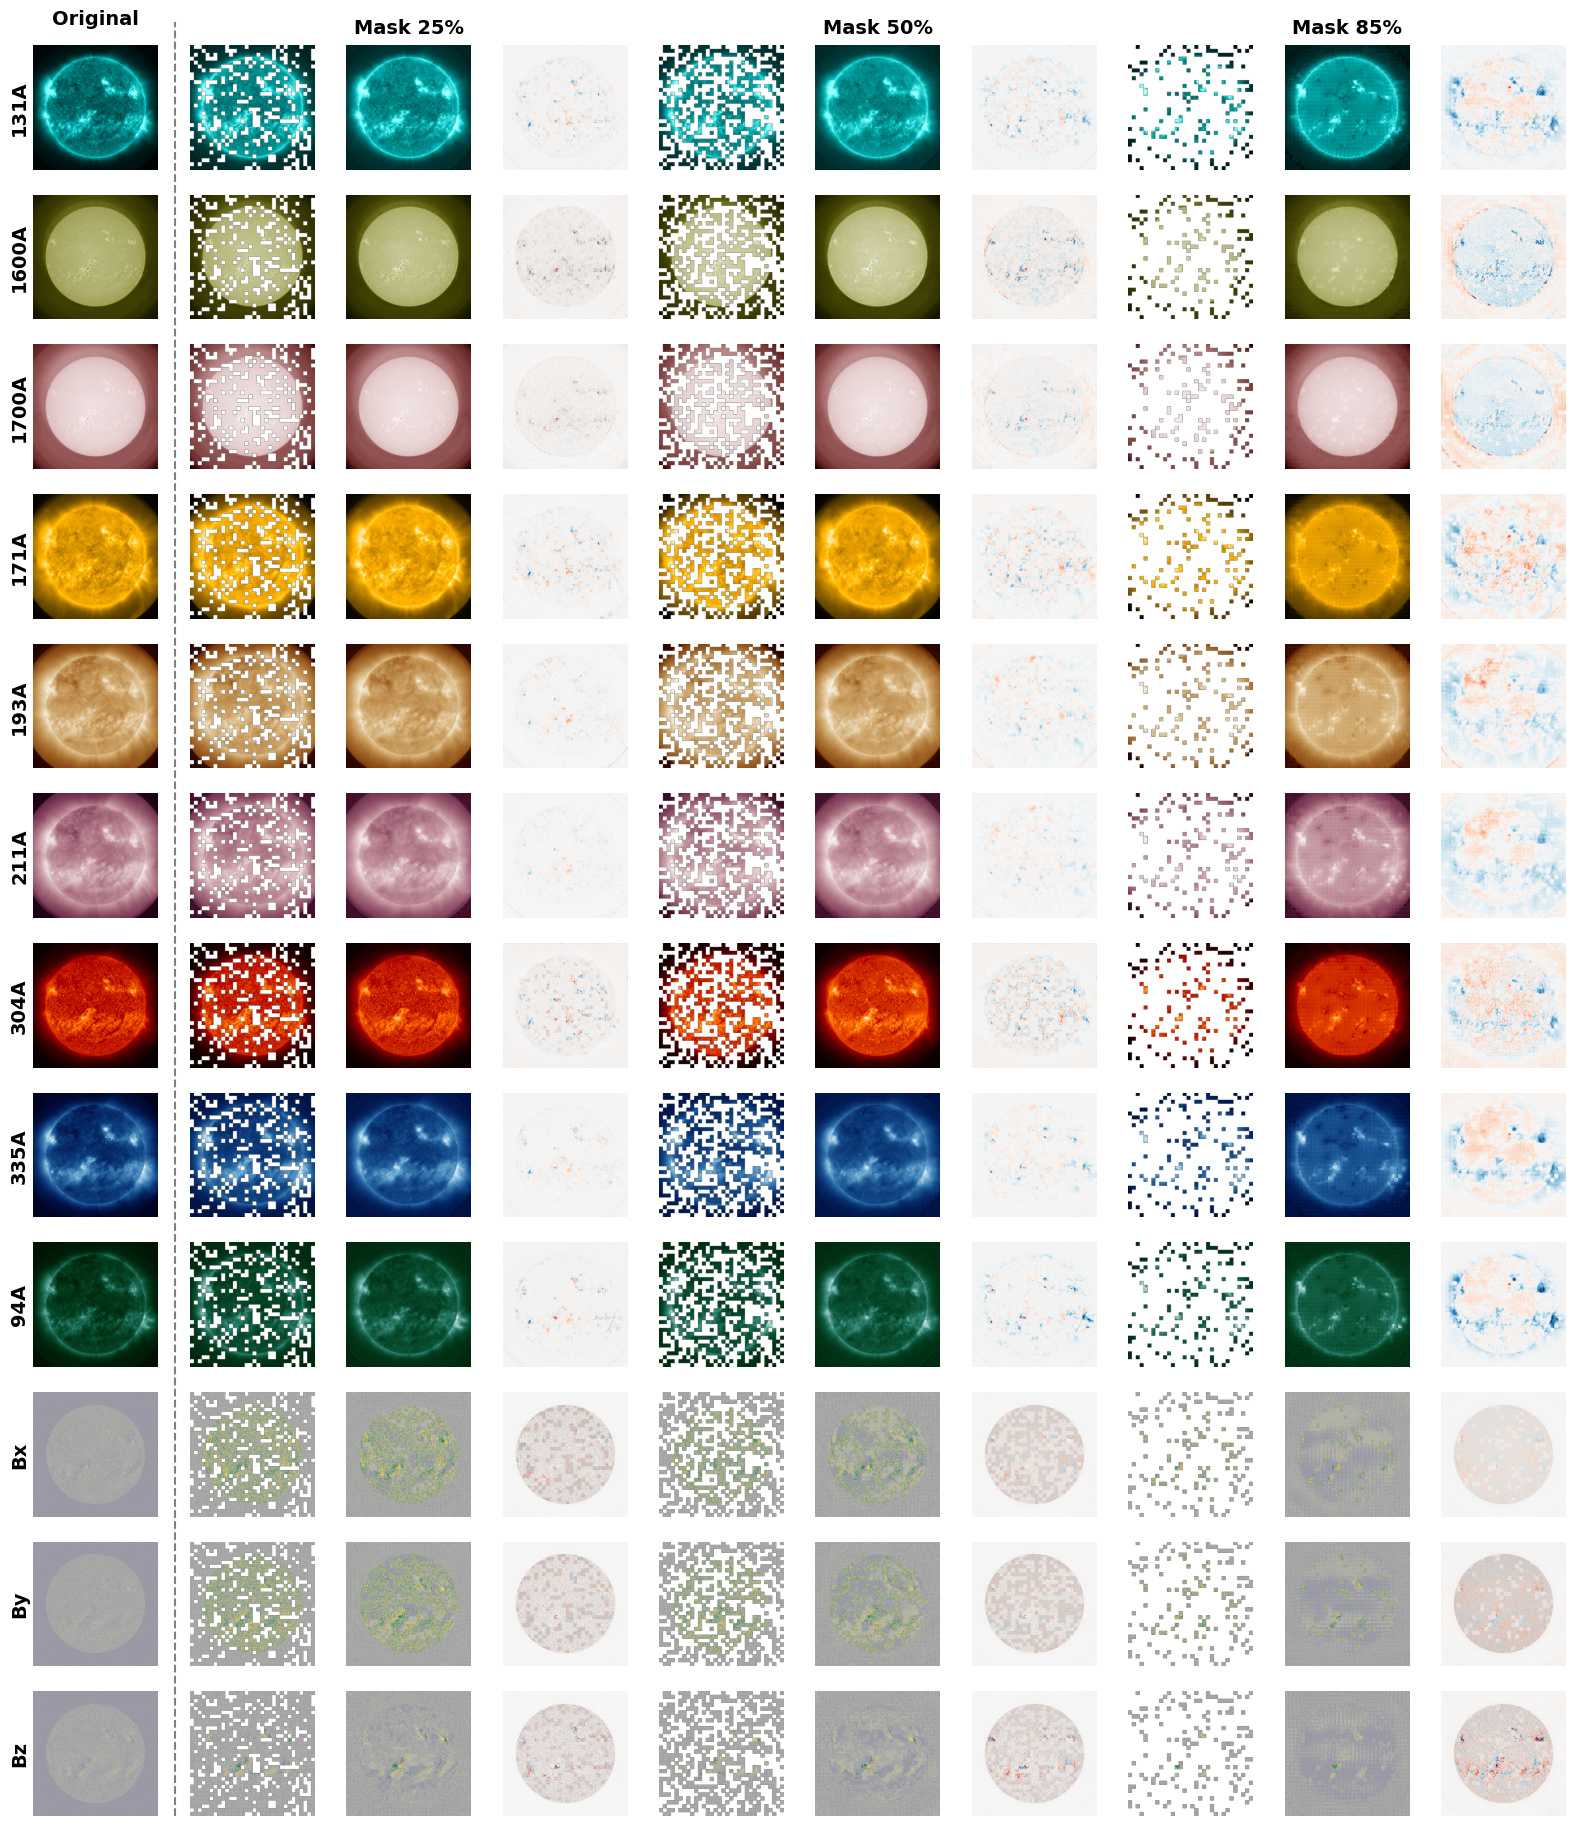

In [12]:
fig = plt.figure(figsize=(20, 23))
gs = gridspec.GridSpec(12, 10, figure=fig, wspace=0.1) # Default gap
norm = TwoSlopeNorm(vmin=-4000, vcenter=0, vmax=4000)

def clean_ax(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

for i_ch, ch_name in enumerate(chan_types):
    ax_ch = fig.add_subplot(gs[i_ch, 0])
    if i_ch == 0:
        ax_ch.set_title("Original", fontsize=14, weight='bold', pad=15)
    ax_ch.imshow(x_set[0, i_ch, 0, :, :], cmap=cms[i_ch], norm=norm if i_ch>=9 else None)
    clean_ax(ax_ch)

    try:
        ax_ch.set_ylabel(f"{ch_name}", fontsize=14, weight='bold',
                         rotation='vertical', ha='center', va='center', labelpad=10)
    except IndexError:
        print(f"Warning: Missing label for channel index {i_ch}")

line_x = 0.20
fig.add_artist(plt.Line2D((line_x, line_x), (0.11, 0.89), color='gray', lw=1.5, ls='--'))

pairs = []
masking_ratio = ["25%", "50%", "85%"]
for masked_imgs, (output_imgs, mask), error, ratio in zip(masked_output, output_list, error_list, masking_ratio):
    pairs.append(
        (masked_imgs, output_imgs, error, ratio)
    )
    

for i, (masked, full, err, percent) in enumerate(pairs):
    
    for i_ch, ch_name in enumerate(chan_types):
        # Left of pair (Masked)
        idx_l = 1 + (i * 3)
        ax_l = fig.add_subplot(gs[i_ch, idx_l])
        ax_l.imshow(masked[i_ch, :, :], cmap=cms[i_ch], norm=norm if i_ch>=9 else None)
        clean_ax(ax_l)
    
        # middle of pair (Reconstructed)
        idx_m = 2 + (i * 3)
        ax_m = fig.add_subplot(gs[i_ch, idx_m])
        ax_m.imshow(full[0, i_ch, 0, :, :], cmap=cms[i_ch], norm=norm if i_ch>=9 else None)
        clean_ax(ax_m)

        # Right of pair (error)
        idx_r = 3 + (i * 3)
        ax_r = fig.add_subplot(gs[i_ch, idx_r])
        ax_r.imshow(err[0, i_ch, 0, :, :], cmap="RdBu_r", norm=norm_aia[i] if i_ch<=9 else norm_hmi[i])
        clean_ax(ax_r)

        if i_ch == 0:
            # Tighten the pair by moving the right image closer to the left
            # This overrides the global wspace for these specific axes
            pos_l = ax_l.get_position()
            pos_r = ax_r.get_position()
            # ax_f.set_position([pos_m.x1, pos_f.y0, pos_f.width, pos_f.height])
        
            # Center title over the pair
            center_x = (pos_l.x0 + pos_r.x1) / 2
            fig.text(center_x, 0.885, f"Mask {percent}", ha='center', fontsize=14, weight="bold")

plt.savefig(f"SDOFMv2_results_per_masking_with_error.pdf", dpi=300, bbox_inches="tight")
plt.show()